# Compare force field parameters

**Author:** Bene  
**Created:** 2026-08-17

**Description:** Compare force field parameters (sigma and epsilon for 103 atoms). UFF and DREIDING forcefields are compared from different sources.

## 0. Imports

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os


pd.set_option("display.max_columns", None)   # all columns
pd.set_option("display.width", None)         # don't wrap to terminal width
pd.set_option("display.max_colwidth", None)  # don't truncate long cell values

# pd.reset_option("display.max_columns")
# pd.reset_option("display.width")
# pd.reset_option("display.max_colwidth")

In [2]:
import os
import sys
import datetime

## 1. Load data

### 1.1 load UFF data (LLM-tanscribed from original paper)

In [3]:
# load data transcriben from original UFF paper (Rappé et al., 1992) (transcribed by Claude)
UFF = pd.read_csv("ff_data/uff_atomic_data_Claude_transcribed.csv")
UFF

,element,atom_type,bond_r1_ang,angle_theta0_deg,nonbond_distance_x1_ang,nonbond_energy_D1_kcal_mol,nonbond_scale_zeta,effective_charge_Z1
0,H,H_,0.354,180.00,2.886,0.044,12.00,0.712
1,H,H_b,0.460,83.50,2.886,0.044,12.00,0.712
2,He,He4+4,0.849,90.00,2.362,0.056,15.24,0.098
3,Li,Li,1.336,180.00,2.451,0.025,12.00,1.026
4,Be,Be3+2,1.074,109.47,2.745,0.085,12.00,1.565
...,...,...,...,...,...,...,...,...
122,Es,Es6+3,1.724,90.00,3.299,0.012,12.00,3.900
123,Fm,Fm6+3,1.712,90.00,3.286,0.012,12.00,3.900
124,Md,Md6+3,1.689,90.00,3.274,0.011,12.00,3.900
125,No,No6+3,1.679,90.00,3.248,0.011,12.00,3.900


In [4]:
# get only data relevant for GCMC / cDFT simulations
# UFF with element unique elements (i.e. no duplicates)
UFF = UFF.drop_duplicates(subset=["element"]).reset_index(drop=True)[["element", "nonbond_distance_x1_ang", "nonbond_energy_D1_kcal_mol"]]
UFF

,element,nonbond_distance_x1_ang,nonbond_energy_D1_kcal_mol
0,H,2.886,0.044
1,He,2.362,0.056
2,Li,2.451,0.025
3,Be,2.745,0.085
4,B,4.083,0.180
...,...,...,...
98,Es,3.299,0.012
99,Fm,3.286,0.012
100,Md,3.274,0.011
101,No,3.248,0.011


In [5]:
# converting kcal/mol to K
J_per_calorie = 4.184 # exact definition (from Rossini's 1935 proposal)
# constants from 1.  Mohr, P. J., Newell, D. B., Taylor, B. N. & Tiesinga, E. Data and analysis for the CODATA 2017 special fundamental constants adjustment*. Metrologia 55, 125 (2018).
# same as in new SI units: 1.  The International System of Units (SI): SI Brochure. https://www.bipm.org/si-brochure-9 (2019) doi:10.59161/AUEZ1291.
N_A = 6.02214076e23 # Avogadro's number (mol-1)
k_B = 1.380649e-23 # Boltzmann constant (J/K)
R = N_A * k_B # ideal gas constant (J/mol/K)

In [6]:
# factor to convert kcal/mol to K
kcal_per_mol2K = 1 * J_per_calorie * 1000 / R
kcal_per_mol2K

503.21953349876577

In [7]:
# convert to sigma to ang and epsilon to K
UFF["sigma_ang"] = UFF["nonbond_distance_x1_ang"].astype(float) / 2**(1/6)
#UFF["epsilon_K"] = UFF["nonbond_energy_D1_kcal_mol"].astype(float) * 503.217 #* 503.27 (likely someone forgot the 1 when creating the UFF.dat (i.e. uff_vincent))
UFF["epsilon_K"] = UFF["nonbond_energy_D1_kcal_mol"].astype(float) * kcal_per_mol2K 

In [8]:
UFF[UFF["element"] == "K"]

,element,nonbond_distance_x1_ang,nonbond_energy_D1_kcal_mol,sigma_ang,epsilon_K
18,K,3.812,0.035,3.396106,17.612684


### 1.2 load DREIDING data (LLM-tanscribed from original paper)

In [9]:
# now lets check for DREIDING atoms:
dreiding = pd.read_csv("ff_data/dreiding_vdw_parameters_Claude_transcribed.csv")
dreiding["sigma_ang"] = dreiding["R0_ang"].astype(float) / 2**(1/6)
#dreiding["epsilon_K"] = dreiding["D0_kcal_mol"].astype(float) * 503.217 #* 503.27 (likely someone forgot the 1 when creating the UFF.dat)
dreiding["epsilon_K"] = dreiding["D0_kcal_mol"].astype(float) * kcal_per_mol2K
dreiding

,atom_type,element,R0_ang,D0_kcal_mol,zeta,source,note,sigma_ang,epsilon_K
0,H,H,3.1950,0.0152,12.382,n-hexane crystal,NaN,2.846421,7.648937
1,H__b,H,3.1950,0.0152,12.382,interpolation,bridging hydrogen variant,2.846421,7.648937
2,H_HB,H,3.1950,0.0001,12.000,H2O dimer,hydrogen-bonding hydrogen variant,2.846421,0.050322
3,B,B,4.0200,0.0950,14.230,interpolation,NaN,3.581413,47.805856
4,C,C,3.8983,0.0951,14.034,Williams,NaN,3.472990,47.856178
5,N,N,3.6621,0.0774,13.843,Williams,NaN,3.262560,38.949192
6,O,O,3.4046,0.0957,13.483,Williams,NaN,3.033154,48.158109
7,F,F,3.4720,0.0725,14.444,Williams,NaN,3.093200,36.483416
8,Al,Al,4.3900,0.3100,12.000,interpolation,NaN,3.911045,155.998055
9,Si,Si,4.2700,0.3100,12.000,interpolation,NaN,3.804138,155.998055


In [10]:
# get only data relevant for GCMC / cDFT simulations
# UFF with element unique elements (i.e. no duplicates)
dreiding = dreiding.drop_duplicates(subset=["element"]).reset_index(drop=True)[["element", "R0_ang", "D0_kcal_mol", "sigma_ang", "epsilon_K"]]
dreiding


,element,R0_ang,D0_kcal_mol,sigma_ang,epsilon_K
0,H,3.1950,0.0152,2.846421,7.648937
1,B,4.0200,0.0950,3.581413,47.805856
2,C,3.8983,0.0951,3.472990,47.856178
3,N,3.6621,0.0774,3.262560,38.949192
4,O,3.4046,0.0957,3.033154,48.158109
5,F,3.4720,0.0725,3.093200,36.483416
6,Al,4.3900,0.3100,3.911045,155.998055
7,Si,4.2700,0.3100,3.804138,155.998055
8,P,4.1500,0.3200,3.697230,161.030251
9,S,4.0300,0.3440,3.590322,173.107520


### 1.3 load RASPA2 example parameter (UFF / DREIDING)

In [11]:
"""Parse a RASPA-style ``force_field_mixing_rules.def`` file into a DataFrame."""

from __future__ import annotations

import re
from pathlib import Path

import pandas as pd

# One interaction entry: name, interaction type, 0..n numeric parameters,
# optionally followed by a "// source" comment.
_ENTRY_RE = re.compile(
    r"""
    (?P<element>\S+) \s+
    (?P<interaction>lennard-jones|none) \b
    (?P<params>(?: \s+ [-+]?\d+(?:\.\d*)?(?:[eE][-+]?\d+)? )*)
    (?: \s* // \s* (?P<source>.*?) )?
    \s*$
    """,
    re.VERBOSE | re.IGNORECASE,
)

# Used to re-insert line breaks if the file arrives as one collapsed line.
_SPLIT_RE = re.compile(r"\s+(?=\S+\s+(?:lennard-jones|none)\b)", re.IGNORECASE)


def parse_force_field(
    source: str | Path,
    *,
    resolve_idem: bool = True,
) -> pd.DataFrame:
    """Parse force-field interaction definitions.

    Parameters
    ----------
    source:
        Path to a ``.def`` file, or the raw text of one.
    resolve_idem:
        If True, a source of ``"idem"`` is replaced by the previous entry's
        source (as the file intends).

    Returns
    -------
    DataFrame with columns ``element``, ``epsilon_K``, ``sigma_ang``, ``source``.
    Entries without parameters (e.g. ``none``) get NaN for epsilon/sigma.
    """
    text = _read(source)

    # Start every entry on its own line, so text pasted as one collapsed
    # blob parses the same as a real file (no-op for well-formed files).
    text = _SPLIT_RE.sub("\n", text)

    rows = []
    for line in text.splitlines():
        line = line.split("#", 1)[0].strip()  # '#' starts a header/comment
        if not line:
            continue
        match = _ENTRY_RE.fullmatch(line)
        if match is None:
            continue

        params = match["params"].split()
        src = (match["source"] or "").strip()
        rows.append(
            {
                "element": match["element"],
                "epsilon_K": float(params[0]) if len(params) > 0 else float("nan"),
                "sigma_ang": float(params[1]) if len(params) > 1 else float("nan"),
                "source": src or None,
            }
        )

    df = pd.DataFrame(rows, columns=["element", "epsilon_K", "sigma_ang", "source"])
    df["element"] = df["element"].str.replace("_", "")

    if resolve_idem:
        df["source"] = _resolve_idem(df["source"])

    return df


def _resolve_idem(sources: pd.Series) -> list[str | None]:
    """Replace ``"idem"`` with the most recent explicit source."""
    resolved: list[str | None] = []
    previous: str | None = None
    for value in sources:
        if not isinstance(value, str) or not value.strip():
            resolved.append(None)
        elif value.strip().lower() == "idem":
            resolved.append(previous)
        else:
            resolved.append(value)
            previous = value
    return resolved


def _read(source: str | Path) -> str:
    if isinstance(source, Path):
        return source.read_text(encoding="utf-8", errors="replace")
    if "\n" not in source and len(source) < 4096:
        candidate = Path(source)
        try:
            if candidate.is_file():
                return candidate.read_text(encoding="utf-8", errors="replace")
        except OSError:
            pass
    return source

In [12]:
raspa2 = parse_force_field(Path("ff_data/force_field_mixing_rules.def"))
raspa2

,element,epsilon_K,sigma_ang,source
0,O,48.15810,3.03315,"DREIDING S.L. Mayo et al., J. Phys. Chem. 1990, 94, 8897-8909."
1,N,38.94920,3.26256,DREIDING
2,C,47.85620,3.47299,DREIDING
3,F,36.48340,3.09320,DREIDING
4,B,47.80580,3.58141,DREIDING
5,P,161.03000,3.69723,DREIDING
6,S,173.10700,3.59032,DREIDING
7,Cl,142.56200,3.51932,DREIDING
8,Br,186.19100,3.51905,DREIDING
9,H,7.64893,2.84642,DREIDING


In [13]:
# drop fluid elements (keep only rows where source contains "DREIDING" or "UFF")
raspa2[~raspa2["source"].isna() & raspa2["source"].str.contains("DREIDING|UFF")]

,element,epsilon_K,sigma_ang,source
0,O,48.15810,3.03315,"DREIDING S.L. Mayo et al., J. Phys. Chem. 1990, 94, 8897-8909."
1,N,38.94920,3.26256,DREIDING
2,C,47.85620,3.47299,DREIDING
3,F,36.48340,3.09320,DREIDING
4,B,47.80580,3.58141,DREIDING
5,P,161.03000,3.69723,DREIDING
6,S,173.10700,3.59032,DREIDING
7,Cl,142.56200,3.51932,DREIDING
8,Br,186.19100,3.51905,DREIDING
9,H,7.64893,2.84642,DREIDING


### 1.4 load UFF_vincent.dat

In [14]:
# 1. load the UFF.dat parameters
import pandas as pd

uff_vincent = pd.read_csv(
    "ff_data/UFF_vincent_2025.dat",
    sep=r"\s+",
    header=None,
    names=["element", "sigma_ang", "epsilon_K", "mass_amu"],
)
uff_vincent["source"] = "UFF"

In [15]:
uff_vincent

,element,sigma_ang,epsilon_K,mass_amu,source
0,Ac,3.0985,16.6080,227.000000,UFF
1,Ag,2.8045,18.1178,107.868200,UFF
2,Al,4.0082,254.1520,26.981538,UFF
3,Am,3.0121,7.0458,243.000000,UFF
4,Ar,3.4460,93.1052,39.948000,UFF
...,...,...,...,...,...
98,Xe,3.9235,167.0861,131.293000,UFF
99,Y,2.9801,36.2355,88.905850,UFF
100,Yb,2.9890,114.7458,173.054000,UFF
101,Zn,2.4616,62.4056,65.380000,UFF


### 1.5 force_field.template (Wei's gcmc july 2026)

In [16]:
from jinja2 import Template
import json

with open("ff_data/force_field_wei_July_2026.template") as f:
    rendered = Template(f.read()).render(cutoff_radius="NaN")

ff_wei = json.loads(rendered)

In [17]:
ff_wei["PseudoAtoms"].__len__(), ff_wei["SelfInteractions"].__len__(), ff_wei["MixingRule"], ff_wei["TruncationMethod"], ff_wei["TailCorrections"]

(107, 107, 'Lorentz-Berthelot', 'truncated', True)

In [18]:
i = 45 # between 0 and 106
ff_wei["PseudoAtoms"][i], ff_wei["SelfInteractions"][i]

({'name': 'Pd',
  'framework': True,
  'print_to_output': True,
  'element': 'Pd',
  'print_as': 'Pd',
  'mass': 106.42,
  'charge': 0.0,
  'source': 'UFF'},
 {'name': 'Pd',
  'type': 'lennard-jones',
  'parameters': [24.15454, 2.58272],
  'source': 'UFF'})

In [19]:
def get_parameters(element):
    """
    Get the parameters for a given element from the UFF.dat file.
    """
    atoms = ff_wei["PseudoAtoms"]
    idx = next(i for i, a in enumerate(atoms) if a["name"] == element)

    mass_amu = ff_wei["PseudoAtoms"][idx]["mass"]
    epsilon_K, sigma_ang = ff_wei["SelfInteractions"][idx]["parameters"]
    return mass_amu, epsilon_K, sigma_ang


In [20]:
def get_df_of_ff():
    """
    Get a DataFrame of the force field parameters.
    """
    for i in range(len(ff_wei["PseudoAtoms"])):
        element = ff_wei["PseudoAtoms"][i]["name"]
        mass_amu, epsilon_K, sigma_ang = get_parameters(element)

        assert ff_wei["PseudoAtoms"][i]["source"] == ff_wei["SelfInteractions"][i]["source"]
        source = ff_wei["SelfInteractions"][i]["source"]
        yield {
            "element": element,
            "sigma_ang": sigma_ang,
            "epsilon_K": epsilon_K,
            "mass_amu": mass_amu,
            "source": source
        }

ff_wei = pd.DataFrame(get_df_of_ff())

In [21]:
ff_wei#.to_csv("ff_wei_DREIDING_UFF_with_source.dat", sep=" ", header=False, index=False,  columns=["element", "sigma_ang", "epsilon_K", "mass_amu", "source"])

,element,sigma_ang,epsilon_K,mass_amu,source
0,H,2.84642,7.648938,1.00794,"DREIDING S.L. Mayo et al., J. Phys. Chem. 1990, 94, 8897-8909."
1,B,3.58141,47.805800,10.81100,DREIDING
2,C,3.47299,47.856200,12.01070,DREIDING
3,N,3.26256,38.949200,14.00674,DREIDING
4,O,3.03315,48.158100,15.99940,DREIDING
...,...,...,...,...,...
102,H_NH3,1.00000,0.000000,1.00794,"TraPPE,"
103,M_NH3,1.00000,0.000000,0.00000,"TraPPE,"
104,Ow,3.15890,93.200000,15.99940,"TIP4P/2005, J.L.F. Abascal and C. Vega, J. Chem. Phys. 2005, 123, 234505."
105,Hw,1.00000,0.000000,1.00794,"TIP4P/2005, J.L.F. Abascal and C. Vega, J. Chem. Phys. 2005, 123, 234505."


In [22]:
ff_wei["source"].unique()

array(['DREIDING  S.L. Mayo et al., J. Phys. Chem. 1990, 94, 8897-8909.',
       'DREIDING',
       'UFF A.K. Rappé et al., J. Am. Chem. Soc. 1992, 114, 10024-10035.',
       'UFF',
       'J.O. Hirschfelder et al., Molecular Theory of Gases and Liquids, Wiley, New York, 1954, p. 1114.',
       'TraPPE, J. Potoff, and J.I. Siepmann, AIChE J. 47, 1676-1682 (2001).',
       'TraPPE, M.G. Martin, and J.I. Siepmann, J. Phys. Chem. B 102, 2569-2577 (1998)',
       'TraPPE,',
       'TIP4P/2005, J.L.F. Abascal and C. Vega, J. Chem. Phys. 2005, 123, 234505.'],
      dtype=object)

In [23]:
# drop fluid elements (keep only rows where source contains "DREIDING" or "UFF")
ff_wei = ff_wei[ff_wei["source"].str.contains("DREIDING|UFF")]
ff_wei

,element,sigma_ang,epsilon_K,mass_amu,source
0,H,2.84642,7.648938,1.00794,"DREIDING S.L. Mayo et al., J. Phys. Chem. 1990, 94, 8897-8909."
1,B,3.58141,47.805800,10.81100,DREIDING
2,C,3.47299,47.856200,12.01070,DREIDING
3,N,3.26256,38.949200,14.00674,DREIDING
4,O,3.03315,48.158100,15.99940,DREIDING
...,...,...,...,...,...
90,Cf,2.95155,6.541850,251.07960,UFF
91,Es,2.93907,6.038630,252.08290,UFF
92,Fm,2.92749,6.038630,257.09510,UFF
93,Md,2.91680,5.535420,258.09510,UFF


### 1.6 load test data

In [24]:
# 1. load the UFF.dat parameters
import pandas as pd

test_ff = pd.read_csv(
    "ff_data/test_ff.dat",
    sep=r"\s+",
    header=None,
    names=["element", "sigma_ang", "epsilon_K", "mass_amu"],
)
test_ff["source"] = "UFF"

In [25]:
test_ff

,element,sigma_ang,epsilon_K,mass_amu,source
0,Ac,3.0985,16.6080,227.0000,UFF
1,Ag,1.8045,18.1178,107.8682,UFF


## 2. Function definitions (to compare and plot data)

### function definitions

#### df compare functions

In [26]:
def get_comparison_df(df_uff, force_field_name="UFF"):
    """
    Get a DataFrame comparing the provided force field parameters to the UFF parameters.
    """
    assert force_field_name in ["UFF", "DREIDING"], f"force_field_name must be 'UFF' or 'DREIDING', got {force_field_name}"
    suffix = "_UFF" if force_field_name == "UFF" else ("_DREIDING" if force_field_name == "DREIDING" else None)

    df_compare = pd.merge(df_uff, UFF if force_field_name == "UFF" else (dreiding if force_field_name == "DREIDING" else None), on="element", how="inner", suffixes=("_provided", suffix))
    df_compare["sigma_ang_abs_error"] = (df_compare["sigma_ang_provided"] - df_compare["sigma_ang" + suffix])#.abs()
    df_compare["sigma_ang_rel_error"] = df_compare["sigma_ang_abs_error"] / df_compare["sigma_ang" + suffix]
    df_compare["epsilon_K_abs_error"] = (df_compare["epsilon_K_provided"] - df_compare["epsilon_K" + suffix])#.abs()
    df_compare["epsilon_K_rel_error"] = df_compare["epsilon_K_abs_error"] / df_compare["epsilon_K" + suffix]

    return df_compare

def get_missing_and_additional_elements(df_uff, UFF):
    """
    Get the missing and additional elements in the provided force field parameters.
    """
    missing_uff = set(UFF["element"]) - set(df_uff["element"])
    additional_uff = set(df_uff["element"]) - set(UFF["element"])
    return missing_uff, additional_uff

def get_elements_provided(df_uff, UFF):

    missing_uff, additional_uff = get_missing_and_additional_elements(df_uff, UFF)

    if "Lw" in missing_uff and "Lr" in additional_uff:
        print("Lw is called Lr (i.e. the same element) in provided ff. renaming Lr to Lw in provided ff.")
        df_uff.loc[df_uff["element"] == "Lr", "element"] = "Lw"
        missing_uff, additional_uff = get_missing_and_additional_elements(df_uff, UFF)

    provided_uff_elements = set(df_uff["element"])

    assert additional_uff == set(), f"additional elements in provided ff: {additional_uff} (these are not defined in UFF.....)"

    print(f"{len(provided_uff_elements)}/{len(UFF['element'])} elements provided (for this ff): {provided_uff_elements}.")
    print(f"{len(missing_uff)}/{len(UFF['element'])} elements missing (for this ff): {missing_uff}.")

In [27]:
def compare(df_compare, label="sigma_ang"):
    print(f"of the {len(df_compare)} elements provided, the average absolute error in {label.split('_')[0]} is {df_compare[label + '_abs_error'].mean():.4f} angstroms, and the average relative error is {df_compare[label + '_rel_error'].mean():.4%}.")
    print(f"min absolute error in {label.split('_')[0]} is {df_compare[label + '_abs_error'].min():.4f} {'angstroms' if label.split('_')[0] == 'sigma' else 'K'} [for {df_compare.loc[df_compare[label + '_abs_error'].idxmin(), 'element'] if not pd.isna(df_compare[label + '_abs_error'].min()) else 'n/a'}], and the min relative error is {df_compare[label + '_rel_error'].min():.4%} [for {df_compare.loc[df_compare[label + '_rel_error'].idxmin(), 'element'] if not pd.isna(df_compare[label + '_rel_error'].min()) else 'n/a'}].")
    print(f"max absolute error in {label.split('_')[0]} is {df_compare[label + '_abs_error'].max():.4f} {'angstroms' if label.split('_')[0] == 'sigma' else 'K'} [for {df_compare.loc[df_compare[label + '_abs_error'].idxmax(), 'element'] if not pd.isna(df_compare[label + '_abs_error'].max()) else 'n/a'}], and the max relative error is {df_compare[label + '_rel_error'].max():.4%} [for {df_compare.loc[df_compare[label + '_rel_error'].idxmax(), 'element'] if not pd.isna(df_compare[label + '_rel_error'].max()) else 'n/a'}].")
    relative_error_threshold = 0.001
    print(f"# of elements with abs relative error > {relative_error_threshold * 100:.2f}%: {len(df_compare[df_compare[label + '_rel_error'].abs() > relative_error_threshold])} ({len(df_compare[df_compare[label + '_rel_error'].abs() > relative_error_threshold]) / len(df_compare) * 100 if len(df_compare) > 0 else 0:.2f}% of set): {df_compare[df_compare[label + '_rel_error'].abs() > relative_error_threshold]['element'].tolist()}")


In [28]:
"""Plot per-element relative and absolute errors, flagging >1 sigma outliers.""" # from claude

from __future__ import annotations

import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

# --- design tokens -----------------------------------------------------------
SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#8a8880"
SERIES = "#2a78d6"  # categorical slot 1 - in-band points
CRITICAL = "#d03b3b"  # status: critical - out-of-band points

UNITS = {"sigma_ang": "Å", "epsilon_K": "K"}


def plot_error_profile(
    df: pd.DataFrame,
    quantity: str = "sigma_ang",
    *,
    element_col: str = "element",
    n_std: float = 1.0,
    rel_as_percent: bool = True,
    unit: str | None = None,
    savepath: str | None = None,
) -> tuple[plt.Figure, pd.DataFrame]:
    """Two stacked panels for one quantity: relative error on top, absolute below.

    Elements are sorted alphabetically on the x axis. Points further than
    ``n_std`` standard deviations from that panel's mean are drawn in red and
    listed, with their deviation, in the panel legend.

    Parameters
    ----------
    df:
        Must contain ``element_col``, ``f"{quantity}_rel_error"`` and
        ``f"{quantity}_abs_error"``.
    quantity:
        Column prefix, e.g. ``"sigma_ang"`` or ``"epsilon_K"``.
    n_std:
        Width of the band, in standard deviations, that defines an outlier.
    rel_as_percent:
        Multiply the relative error by 100 and label it in %.
    unit:
        Unit for the absolute error; inferred from ``quantity`` when omitted.

    Returns
    -------
    ``(figure, outliers)`` where ``outliers`` has columns ``element``,
    ``panel``, ``value`` and ``deviation_std``.
    """
    rel_col, abs_col = f"{quantity}_rel_error", f"{quantity}_abs_error"
    missing = [c for c in (element_col, rel_col, abs_col) if c not in df.columns]
    if missing:
        raise KeyError(f"missing column(s): {missing}")

    data = (
        df[[element_col, rel_col, abs_col]]
        .sort_values(element_col, key=lambda s: s.astype(str).str.lower())
        .reset_index(drop=True)
    )
    elements = data[element_col].astype(str).to_numpy()
    x = np.arange(len(elements))

    if unit is None:
        unit = UNITS.get(quantity, "")
    rel_scale = 100.0 if rel_as_percent else 1.0

    panels = [
        (rel_col, "relative error", "%" if rel_as_percent else "", rel_scale),
        (abs_col, "absolute error", unit, 1.0),
    ]

    plot_width = max(9.0, 0.145 * len(elements))
    fig, axes = plt.subplots(
        2, 1, figsize=(plot_width, 8.2), sharex=True, facecolor=SURFACE,
    )

    all_outliers, legend_cols = [], [1]
    for ax, (col, panel_name, panel_unit, scale) in zip(axes, panels):
        y = pd.to_numeric(data[col], errors="coerce").to_numpy(dtype=float) * scale
        finite = np.isfinite(y)
        mean = float(np.nanmean(y[finite])) if finite.any() else float("nan")
        std = float(np.nanstd(y[finite], ddof=1)) if finite.sum() > 1 else 0.0

        deviation = np.abs(y - mean) / std if std > 0 else np.zeros_like(y)
        is_out = finite & (deviation > n_std)

        _draw_panel(
            ax, x, y, is_out, mean, std, n_std,
            ylabel=_axis_label(panel_name, panel_unit),
        )
        legend_cols.append(_outlier_legend(ax, elements, y, is_out, panel_unit, n_std))

        order = np.argsort(-deviation[is_out]) if is_out.any() else []
        all_outliers.append(
            pd.DataFrame(
                {
                    "element": elements[is_out][order],
                    "panel": panel_name,
                    "value": y[is_out][order] / scale,
                    "deviation_std": deviation[is_out][order],
                }
            )
        )

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(elements, rotation=90, fontsize=6.5, color=INK_SECONDARY)
    axes[-1].set_xlim(-1, len(elements))
    axes[-1].set_xlabel("element", fontsize=10, color=INK_SECONDARY, labelpad=6)

    axes[0].set_title(
        f"{quantity}: per-element error  ·  red = further than {n_std:g}σ from the mean",
        fontsize=13, color=INK, loc="left", pad=12,
    )

    # Reserve room on the right for the outlier legends (margins set in inches,
    # because tight_layout cannot see artists placed outside the axes).
    legend_in = 0.3 + 1.6 * max(legend_cols)
    total_w = plot_width + legend_in
    fig.set_size_inches(total_w, 8.2)
    fig.subplots_adjust(
        left=0.85 / total_w, right=1 - legend_in / total_w,
        bottom=0.95 / 8.2, top=1 - 0.55 / 8.2, hspace=0.16,
    )

    if savepath:
        fig.savefig(savepath, dpi=160, bbox_inches="tight", facecolor=SURFACE)

    return fig, pd.concat(all_outliers, ignore_index=True)


def _axis_label(name: str, unit: str) -> str:
    return f"{name} [{unit}]" if unit else name


def _draw_panel(ax, x, y, is_out, mean, std, n_std, *, ylabel: str) -> None:
    ax.set_facecolor(SURFACE)
    if math.isfinite(mean) and std > 0:
        ax.axhspan(
            mean - n_std * std, mean + n_std * std,
            color=INK_MUTED, alpha=0.10, zorder=0, lw=0,
        )
        ax.axhline(mean, color=INK_MUTED, lw=1, ls="--", dashes=(4, 3), zorder=1)
    if np.nanmin(y) < 0 < np.nanmax(y):
        ax.axhline(0, color=INK_MUTED, lw=1, zorder=1)

    ax.scatter(x[~is_out], y[~is_out], s=34, color=SERIES, lw=0, zorder=3)
    ax.scatter(
        x[is_out], y[is_out], s=72, color=CRITICAL,
        edgecolor=SURFACE, linewidth=1.4, zorder=4,
    )

    ax.set_ylabel(ylabel, fontsize=10, color=INK_SECONDARY)
    ax.tick_params(axis="y", labelsize=9, colors=INK_SECONDARY, length=3)
    ax.grid(axis="y", color=INK_MUTED, alpha=0.20, lw=0.6)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(INK_MUTED)
        ax.spines[side].set_linewidth(0.8)


def _outlier_legend(ax, elements, y, is_out, unit, n_std) -> int:
    """List each flagged element and its value in a legend beside the panel."""
    suffix = f" {unit}" if unit and unit != "%" else ("%" if unit == "%" else "")
    order = np.argsort(-np.abs(y[is_out] - np.nanmean(y[np.isfinite(y)])))
    labels = [
        f"{el}  {val:+.3g}{suffix}"
        for el, val in zip(elements[is_out][order], y[is_out][order])
    ]
    if not labels:
        labels = ["none"]

    handles = [
        Line2D([], [], marker="o", ls="", markersize=6, color=CRITICAL,
               markeredgecolor=SURFACE, markeredgewidth=1.0)
        for _ in labels
    ]
    ncol = max(1, math.ceil(len(labels) / 12))
    ax.legend(
        handles, labels,
        title=f"outside ±{n_std:g}σ  (n={int(is_out.sum())})",
        loc="upper left", bbox_to_anchor=(1.005, 1.02), ncol=ncol,
        frameon=False, fontsize=7.5, title_fontsize=8.5,
        labelcolor=INK_SECONDARY, handletextpad=0.5,
        columnspacing=1.1, labelspacing=0.35, borderaxespad=0,
    )
    ax.get_legend().get_title().set_color(INK)
    return ncol


# if __name__ == "__main__":
#     # plot_error_profile(df_compare_both, "sigma_ang", savepath="sigma.png")
#     # plot_error_profile(df_compare_both, "epsilon_K", savepath="epsilon.png")
#     pass

#### manual

In [29]:
df = raspa2
df = ff_wei
#df = uff_vincent

df_uff = df[df["source"].str.contains("UFF", na=False)]
df_dreiding = df[df["source"].str.contains("DREIDING", na=False)]

assert not df_uff["source"].str.contains("DREIDING", na=False).any(), "df_uff contains DREIDING"
assert not df_dreiding["source"].str.contains("UFF", na=False).any(), "df_dreiding contains UFF"

assert {"element", "source", "epsilon_K", "sigma_ang"}.issubset(df.columns), f"df columns: {df.columns}, expected: {'element', 'source', 'epsilon_K', 'sigma_ang'}"
print(f"given df has {df.shape[0]} parameter entries for {df['element'].nunique()} unique elements.")
print(f"# uff parameters: {df_uff.shape[0]}, # dreiding parameters: {df_dreiding.shape[0]}")

print(f"comparing entries to {len(UFF)} UFF parameters:")
print(f"___UFF___")
get_elements_provided(df_uff, UFF)

df_uff_compare = get_comparison_df(df_uff, force_field_name="UFF")
df_uff_compare


given df has 95 parameter entries for 95 unique elements.
# uff parameters: 74, # dreiding parameters: 21
comparing entries to 103 UFF parameters:
___UFF___
74/103 elements provided (for this ff): {'Ho', 'W', 'Bk', 'Am', 'K', 'Ni', 'Ru', 'Pr', 'Er', 'Np', 'Rh', 'Cr', 'Zr', 'Ca', 'Tb', 'Tm', 'Ce', 'Ta', 'Cu', 'Hg', 'Ir', 'Tc', 'Fe', 'Pb', 'Ra', 'Re', 'Os', 'No', 'Sr', 'Na', 'Sc', 'Nd', 'Nb', 'Gd', 'Es', 'U', 'Mn', 'Th', 'Cf', 'Ag', 'Md', 'Zn', 'Au', 'Sm', 'At', 'Ti', 'Tl', 'Cd', 'Co', 'Cs', 'Mg', 'Yb', 'Mo', 'Rb', 'Lu', 'Ac', 'Hf', 'Pa', 'Pu', 'Pd', 'Dy', 'Eu', 'Be', 'La', 'V', 'Ba', 'Pm', 'Bi', 'Po', 'Rn', 'Y', 'Fm', 'Cm', 'Pt'}.
29/103 elements missing (for this ff): {'H', 'P', 'Kr', 'He', 'Ga', 'N', 'Xe', 'Li', 'In', 'I', 'B', 'Lw', 'S', 'Si', 'O', 'Se', 'As', 'Te', 'C', 'Fr', 'F', 'Ge', 'Cl', 'Br', 'Ne', 'Sn', 'Ar', 'Sb', 'Al'}.


,element,sigma_ang_provided,epsilon_K_provided,mass_amu,source,nonbond_distance_x1_ang,nonbond_energy_D1_kcal_mol,sigma_ang_UFF,epsilon_K_UFF,sigma_ang_abs_error,sigma_ang_rel_error,epsilon_K_abs_error,epsilon_K_rel_error
0,Na,2.65755,15.09659,22.98977,"UFF A.K. Rappé et al., J. Am. Chem. Soc. 1992, 114, 10024-10035.",2.983,0.030,2.657551,15.096586,-8.762126e-07,-3.297068e-07,0.000004,2.646318e-07
1,Mg,2.69141,55.85737,24.30500,UFF,3.021,0.111,2.691405,55.857368,4.972498e-06,1.847547e-06,0.000002,3.189619e-08
2,K,3.39611,17.61269,39.09830,UFF,3.812,0.035,3.396106,17.612684,4.086449e-06,1.203275e-06,0.000006,3.592606e-07
3,Ca,3.02816,119.76626,40.07800,UFF,3.399,0.238,3.028165,119.766249,-4.742959e-06,-1.566282e-06,0.000011,9.207347e-08
4,Sc,2.93551,9.56117,44.95591,UFF,3.295,0.019,2.935511,9.561171,-1.276272e-06,-4.347701e-07,-0.000001,-1.188637e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,Cf,2.95155,6.54185,251.07960,UFF,3.313,0.013,2.951547,6.541854,2.546801e-06,8.628698e-07,-0.000004,-6.015854e-07
70,Es,2.93907,6.03863,252.08290,UFF,3.299,0.012,2.939075,6.038634,-4.871145e-06,-1.657374e-06,-0.000004,-7.289703e-07
71,Fm,2.92749,6.03863,257.09510,UFF,3.286,0.012,2.927493,6.038634,-3.187809e-06,-1.088921e-06,-0.000004,-7.289703e-07
72,Md,2.91680,5.53542,258.09510,UFF,3.274,0.011,2.916802,5.535415,-2.403191e-06,-8.239130e-07,0.000005,9.270332e-07


In [30]:
compare(df_uff_compare)

of the 74 elements provided, the average absolute error in sigma is 0.0032 angstroms, and the average relative error is 0.1198%.
min absolute error in sigma is -0.0000 angstroms [for Es], and the min relative error is -0.0002% [for Re].
max absolute error in sigma is 0.2387 angstroms [for Cr], and the max relative error is 8.8625% [for Cr].
# of elements with abs relative error > 0.10%: 1 (1.35% of set): ['Cr']


In [31]:
compare(df_uff_compare, label="epsilon_K")

of the 74 elements provided, the average absolute error in epsilon is 0.0204 angstroms, and the average relative error is 0.0724%.
min absolute error in epsilon is -0.0000 K [for Es], and the min relative error is -0.0001% [for Es].
max absolute error in epsilon is 1.5097 K [for Mo], and the max relative error is 5.3571% [for Mo].
# of elements with abs relative error > 0.10%: 1 (1.35% of set): ['Mo']


In [32]:
print(f"___DREIDING___")
get_elements_provided(df_dreiding, dreiding)
df_dreiding_compare = get_comparison_df(df_dreiding, force_field_name="DREIDING")
df_dreiding_compare

___DREIDING___
21/25 elements provided (for this ff): {'H', 'P', 'Ga', 'N', 'In', 'I', 'B', 'S', 'Si', 'O', 'Se', 'As', 'Te', 'C', 'F', 'Ge', 'Cl', 'Br', 'Sn', 'Sb', 'Al'}.
4/25 elements missing (for this ff): {'Na', 'Zn', 'Ca', 'Fe'}.


,element,sigma_ang_provided,epsilon_K_provided,mass_amu,source,R0_ang,D0_kcal_mol,sigma_ang_DREIDING,epsilon_K_DREIDING,sigma_ang_abs_error,sigma_ang_rel_error,epsilon_K_abs_error,epsilon_K_rel_error
0,H,2.84642,7.648938,1.00794,"DREIDING S.L. Mayo et al., J. Phys. Chem. 1990, 94, 8897-8909.",3.1950,0.0152,2.846421,7.648937,-1.404458e-06,-4.934120e-07,1.090819e-06,1.426105e-07
1,B,3.58141,47.805800,10.81100,DREIDING,4.0200,0.0950,3.581413,47.805856,-2.846924e-06,-7.949165e-07,-5.568238e-05,-1.164761e-06
2,C,3.47299,47.856200,12.01070,DREIDING,3.8983,0.0951,3.472990,47.856178,-4.729265e-07,-1.361727e-07,2.236427e-05,4.673225e-07
3,N,3.26256,38.949200,14.00674,DREIDING,3.6621,0.0774,3.262560,38.949192,-1.957017e-07,-5.998410e-08,8.107196e-06,2.081480e-07
4,O,3.03315,48.158100,15.99940,DREIDING,3.4046,0.0957,3.033154,48.158109,-3.775781e-06,-1.244837e-06,-9.355832e-06,-1.942732e-07
5,F,3.09320,36.483400,18.99840,DREIDING,3.4720,0.0725,3.093200,36.483416,-3.493833e-07,-1.129520e-07,-1.617866e-05,-4.434525e-07
6,Al,3.91105,155.998100,26.98200,DREIDING,4.3900,0.3100,3.911045,155.998055,4.627364e-06,1.183153e-06,4.461538e-05,2.859996e-07
7,Si,3.80414,155.998100,28.08500,DREIDING,4.2700,0.3100,3.804138,155.998055,2.473541e-06,6.502238e-07,4.461538e-05,2.859996e-07
8,P,3.69723,161.030300,30.97400,DREIDING,4.1500,0.3200,3.697230,161.030251,3.197176e-07,8.647491e-08,4.928039e-05,3.060319e-07
9,S,3.59032,173.107500,32.06000,DREIDING,4.0300,0.3440,3.590322,173.107520,-1.834106e-06,-5.108471e-07,-1.952358e-05,-1.127829e-07


In [33]:
compare(df_dreiding_compare)

of the 21 elements provided, the average absolute error in sigma is 0.0000 angstroms, and the average relative error is 0.0000%.
min absolute error in sigma is -0.0000 angstroms [for O], and the min relative error is -0.0001% [for O].
max absolute error in sigma is 0.0000 angstroms [for In], and the max relative error is 0.0001% [for In].
# of elements with abs relative error > 0.10%: 0 (0.00% of set): []


In [34]:
compare(df_dreiding_compare, label="epsilon_K")

of the 21 elements provided, the average absolute error in epsilon is 0.0000 angstroms, and the average relative error is 0.0000%.
min absolute error in epsilon is -0.0001 K [for B], and the min relative error is -0.0001% [for B].
max absolute error in epsilon is 0.0001 K [for Te], and the max relative error is 0.0000% [for C].
# of elements with abs relative error > 0.10%: 0 (0.00% of set): []


In [35]:
df_compare_both = pd.concat([df_uff_compare, df_dreiding_compare])
df_compare_both

,element,sigma_ang_provided,epsilon_K_provided,mass_amu,source,nonbond_distance_x1_ang,nonbond_energy_D1_kcal_mol,sigma_ang_UFF,epsilon_K_UFF,sigma_ang_abs_error,sigma_ang_rel_error,epsilon_K_abs_error,epsilon_K_rel_error,R0_ang,D0_kcal_mol,sigma_ang_DREIDING,epsilon_K_DREIDING
0,Na,2.65755,15.09659,22.98977,"UFF A.K. Rappé et al., J. Am. Chem. Soc. 1992, 114, 10024-10035.",2.983,0.030,2.657551,15.096586,-8.762126e-07,-3.297068e-07,0.000004,2.646318e-07,NaN,NaN,NaN,NaN
1,Mg,2.69141,55.85737,24.30500,UFF,3.021,0.111,2.691405,55.857368,4.972498e-06,1.847547e-06,0.000002,3.189619e-08,NaN,NaN,NaN,NaN
2,K,3.39611,17.61269,39.09830,UFF,3.812,0.035,3.396106,17.612684,4.086449e-06,1.203275e-06,0.000006,3.592606e-07,NaN,NaN,NaN,NaN
3,Ca,3.02816,119.76626,40.07800,UFF,3.399,0.238,3.028165,119.766249,-4.742959e-06,-1.566282e-06,0.000011,9.207347e-08,NaN,NaN,NaN,NaN
4,Sc,2.93551,9.56117,44.95591,UFF,3.295,0.019,2.935511,9.561171,-1.276272e-06,-4.347701e-07,-0.000001,-1.188637e-07,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16,In,4.08923,276.77070,114.82000,DREIDING,NaN,NaN,NaN,NaN,4.883736e-06,1.194294e-06,-0.000043,-1.568964e-07,4.59,0.55,4.089225,276.770743
17,Sn,3.98232,276.77080,118.69000,DREIDING,NaN,NaN,NaN,NaN,2.729913e-06,6.855086e-07,0.000057,2.044135e-07,4.47,0.55,3.982317,276.770743
18,Sb,3.87541,276.77080,121.75000,DREIDING,NaN,NaN,NaN,NaN,5.760895e-07,1.486526e-07,0.000057,2.044135e-07,4.35,0.55,3.875409,276.770743
19,Te,3.76850,286.83520,127.60000,DREIDING,NaN,NaN,NaN,NaN,-1.577734e-06,-4.186634e-07,0.000066,2.297686e-07,4.23,0.57,3.768502,286.835134


#### auto

In [36]:
def get_error_force_field(df):
    """returns a dataframe with the errors in sigma and epsilon for the provided force field parameters compared to UFF and DREIDING."""
    df_uff = df[df["source"].str.contains("UFF", na=False)]
    df_dreiding = df[df["source"].str.contains("DREIDING", na=False)]

    assert not df_uff["source"].str.contains("DREIDING", na=False).any(), "df_uff contains DREIDING"
    assert not df_dreiding["source"].str.contains("UFF", na=False).any(), "df_dreiding contains UFF"

    assert {"element", "source", "epsilon_K", "sigma_ang"}.issubset(df.columns), f"df columns: {df.columns}, expected: {'element', 'source', 'epsilon_K', 'sigma_ang'}"
    print(f"given df has {df.shape[0]} parameter entries for {df['element'].nunique()} unique elements.")
    print(f"# uff parameters: {df_uff.shape[0]}, # dreiding parameters: {df_dreiding.shape[0]}")

    print(f"comparing entries to {len(UFF)} UFF parameters:")
    print(f"___UFF___")
    get_elements_provided(df_uff, UFF)
    df_uff_compare = get_comparison_df(df_uff, force_field_name="UFF")
    compare(df_uff_compare)
    compare(df_uff_compare, label="epsilon_K")
    print(f"___DREIDING___")
    get_elements_provided(df_dreiding, dreiding)
    df_dreiding_compare = get_comparison_df(df_dreiding, force_field_name="DREIDING")
    df_dreiding_compare
    compare(df_dreiding_compare)
    compare(df_dreiding_compare, label="epsilon_K")

    # one df for uff and dreiding
    df_compare_both = pd.concat([df_uff_compare, df_dreiding_compare])
    return df_compare_both

In [37]:
df = raspa2
df = ff_wei
df = uff_vincent

In [38]:
df_compare_both = get_error_force_field(ff_wei)

given df has 95 parameter entries for 95 unique elements.
# uff parameters: 74, # dreiding parameters: 21
comparing entries to 103 UFF parameters:
___UFF___
74/103 elements provided (for this ff): {'Ho', 'W', 'Bk', 'Am', 'K', 'Ni', 'Ru', 'Pr', 'Er', 'Np', 'Rh', 'Cr', 'Zr', 'Ca', 'Tb', 'Tm', 'Ce', 'Ta', 'Cu', 'Hg', 'Ir', 'Tc', 'Fe', 'Pb', 'Ra', 'Re', 'Os', 'No', 'Sr', 'Na', 'Sc', 'Nd', 'Nb', 'Gd', 'Es', 'U', 'Mn', 'Th', 'Cf', 'Ag', 'Md', 'Zn', 'Au', 'Sm', 'At', 'Ti', 'Tl', 'Cd', 'Co', 'Cs', 'Mg', 'Yb', 'Mo', 'Rb', 'Lu', 'Ac', 'Hf', 'Pa', 'Pu', 'Pd', 'Dy', 'Eu', 'Be', 'La', 'V', 'Ba', 'Pm', 'Bi', 'Po', 'Rn', 'Y', 'Fm', 'Cm', 'Pt'}.
29/103 elements missing (for this ff): {'H', 'P', 'Kr', 'He', 'Ga', 'N', 'Xe', 'Li', 'In', 'I', 'B', 'Lw', 'S', 'Si', 'O', 'Se', 'As', 'Te', 'C', 'Fr', 'F', 'Ge', 'Cl', 'Br', 'Ne', 'Sn', 'Ar', 'Sb', 'Al'}.
of the 74 elements provided, the average absolute error in sigma is 0.0032 angstroms, and the average relative error is 0.1198%.
min absolute error in sigma

#### plot

In [39]:
df_compare_both[["element", "sigma_ang_abs_error", "sigma_ang_rel_error", "epsilon_K_abs_error", "epsilon_K_rel_error"]]

,element,sigma_ang_abs_error,sigma_ang_rel_error,epsilon_K_abs_error,epsilon_K_rel_error
0,Na,-8.762126e-07,-3.297068e-07,0.000004,2.646318e-07
1,Mg,4.972498e-06,1.847547e-06,0.000002,3.189619e-08
2,K,4.086449e-06,1.203275e-06,0.000006,3.592606e-07
3,Ca,-4.742959e-06,-1.566282e-06,0.000011,9.207347e-08
4,Sc,-1.276272e-06,-4.347701e-07,-0.000001,-1.188637e-07
...,...,...,...,...,...
16,In,4.883736e-06,1.194294e-06,-0.000043,-1.568964e-07
17,Sn,2.729913e-06,6.855086e-07,0.000057,2.044135e-07
18,Sb,5.760895e-07,1.486526e-07,0.000057,2.044135e-07
19,Te,-1.577734e-06,-4.186634e-07,0.000066,2.297686e-07


(<Figure size 1567.5x820 with 2 Axes>,
   element           panel     value  deviation_std
 0      Cr  relative error  0.088625       9.644196
 1      Cr  absolute error  0.238683       9.644196)

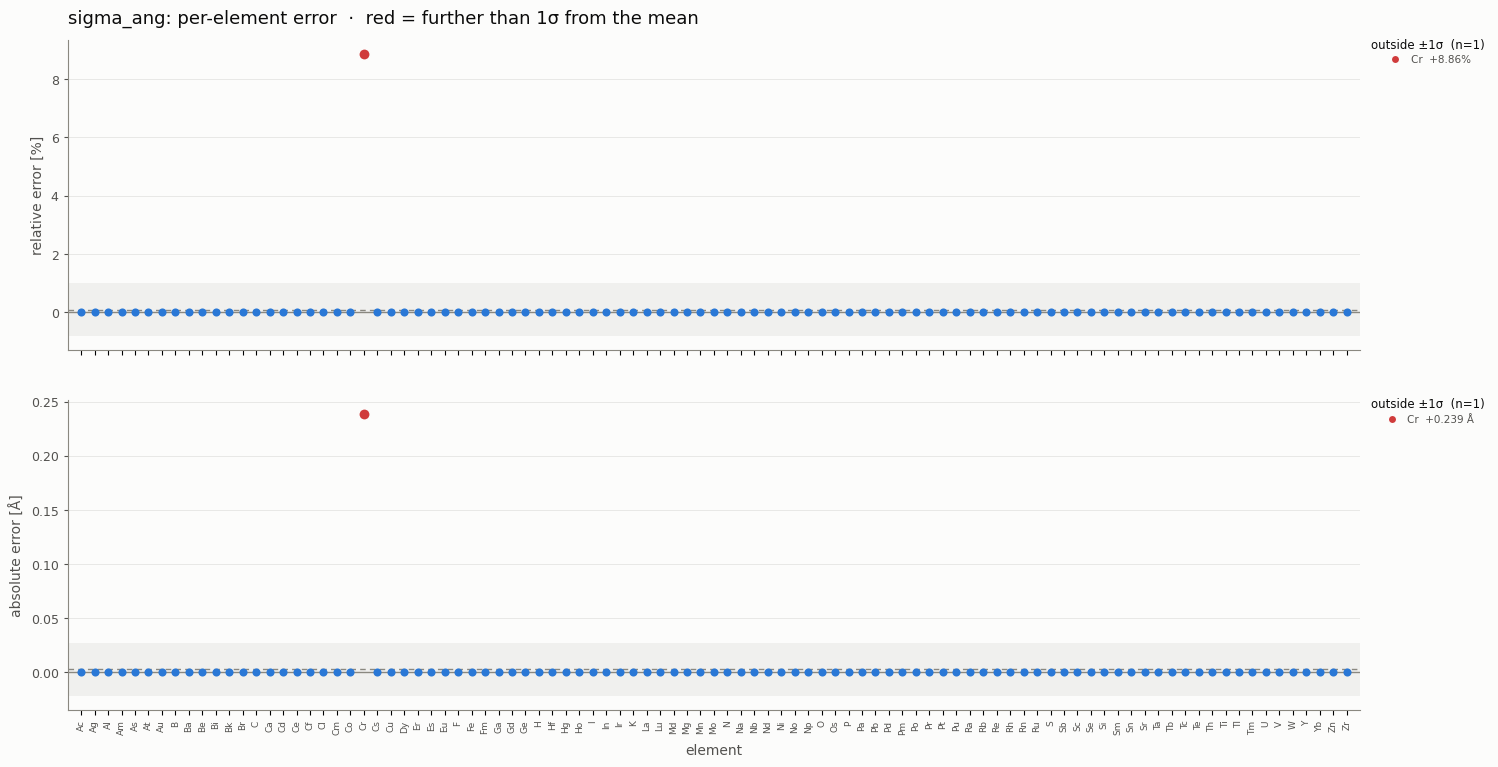

In [40]:
plot_error_profile(df_compare_both, "sigma_ang")

(<Figure size 1567.5x820 with 2 Axes>,
   element           panel     value  deviation_std
 0      Mo  relative error  0.053571       9.644196
 1      Mo  absolute error  1.509656       9.644196)

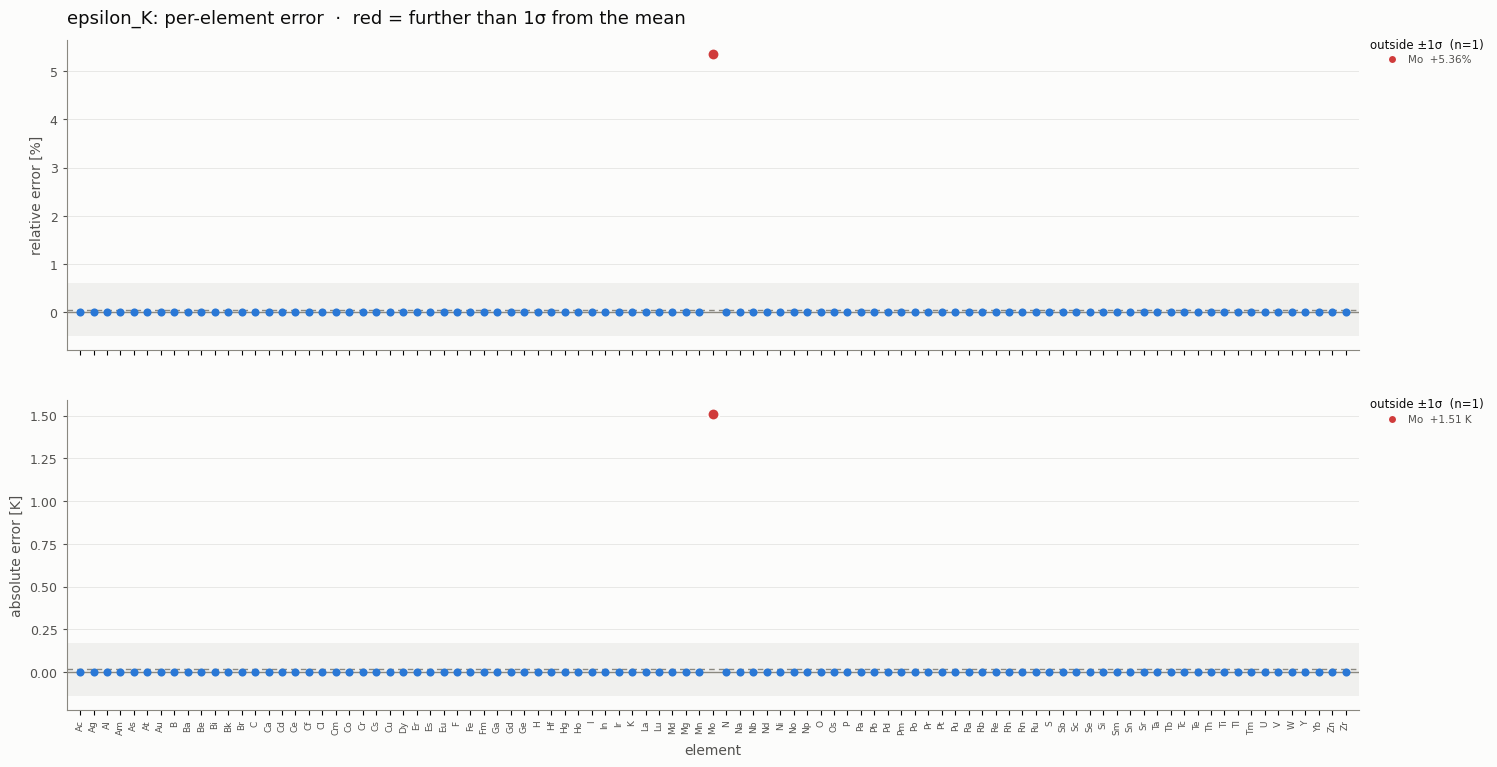

In [41]:
plot_error_profile(df_compare_both, "epsilon_K")

## 3. Compare force field parameters RASPA2 example parameter

### 3.1 Compare RASPA2 example parameters

In [42]:
df_compare_both = get_error_force_field(raspa2)

given df has 46 parameter entries for 45 unique elements.
# uff parameters: 20, # dreiding parameters: 12
comparing entries to 103 UFF parameters:
___UFF___
20/103 elements provided (for this ff): {'Ni', 'Cr', 'Zr', 'Cu', 'Fe', 'Ga', 'Sc', 'Mn', 'Ag', 'In', 'Zn', 'Ti', 'Cd', 'Co', 'Mg', 'Te', 'Ne', 'Be', 'V', 'Sb'}.
83/103 elements missing (for this ff): {'Bk', 'Ru', 'Pb', 'Tm', 'Ta', 'P', 'Tc', 'Ir', 'Os', 'Pt', 'Sr', 'Na', 'Es', 'Nd', 'Xe', 'Li', 'Th', 'Au', 'I', 'B', 'Tl', 'S', 'O', 'Se', 'Yb', 'As', 'C', 'Fr', 'Rb', 'Hf', 'Pd', 'Ge', 'Cl', 'Ar', 'Bi', 'Pm', 'Po', 'Cm', 'H', 'Ho', 'W', 'Am', 'K', 'Np', 'Pr', 'Er', 'Rh', 'Hg', 'Ca', 'Tb', 'Ra', 'Ce', 'No', 'Kr', 'He', 'Re', 'N', 'Nb', 'Md', 'U', 'Cf', 'Gd', 'Sm', 'At', 'Lw', 'Si', 'Cs', 'Mo', 'F', 'Ac', 'Lu', 'Pa', 'Pu', 'Dy', 'Eu', 'Br', 'Sn', 'La', 'Ba', 'Rn', 'Fm', 'Y', 'Al'}.
of the 20 elements provided, the average absolute error in sigma is 0.0000 angstroms, and the average relative error is 0.0000%.
min absolute error in sigma

(<Figure size 1250x820 with 2 Axes>,
    element           panel         value  deviation_std
 0       Mg  relative error  1.847547e-06       1.964716
 1       Ne  relative error -1.572391e-06       1.886258
 2        V  relative error  1.581646e-06       1.665301
 3       Zn  relative error -1.283020e-06       1.560415
 4        O  relative error -1.244837e-06       1.517420
 5       Ti  relative error -1.212646e-06       1.481172
 6       Be  relative error  1.234383e-06       1.274271
 7       Ni  relative error  1.201197e-06       1.236902
 8       Al  relative error  1.183153e-06       1.216584
 9       Cr  relative error  1.178924e-06       1.211822
 10      Fe  relative error  1.130470e-06       1.157261
 11       B  relative error -7.949165e-07       1.010793
 12      Ne  absolute error -4.542929e-06       1.852919
 13      Mg  absolute error  4.972498e-06       1.793931
 14      Al  absolute error  4.627364e-06       1.661656
 15       V  absolute error  4.430167e-06       1.5

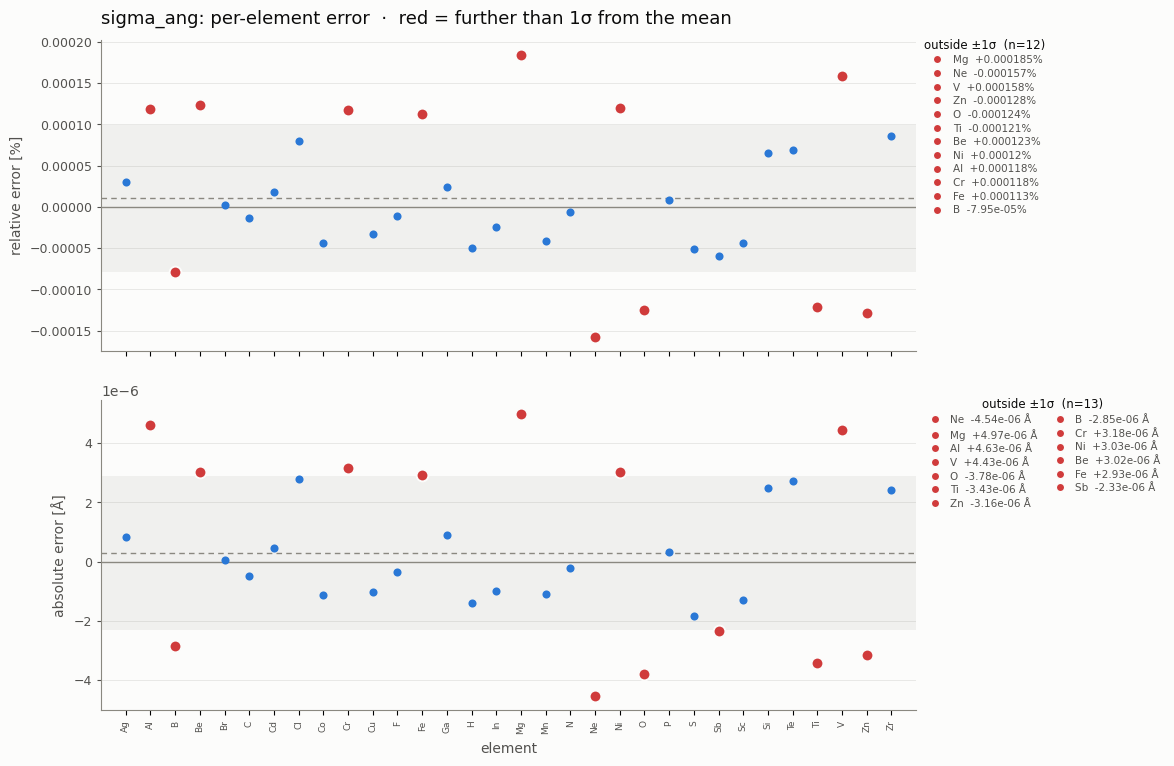

In [43]:
plot_error_profile(df_compare_both, "sigma_ang")

(<Figure size 1090x820 with 2 Axes>,
    element           panel         value  deviation_std
 0       Sb  relative error  1.900719e-06       2.767422
 1        S  relative error -3.001161e-06       2.758043
 2       Cu  relative error  9.270332e-07       1.669871
 3       Te  relative error -1.869033e-06       1.481893
 4       Mg  relative error  5.689784e-07       1.266266
 5       In  relative error -1.660645e-06       1.246995
 6        C  relative error  4.673225e-07       1.151678
 7        P  relative error -1.556972e-06       1.130134
 8       Sb  absolute error  4.294591e-04       2.930278
 9        S  absolute error -5.195236e-04       2.719219
 10      In  absolute error -5.005658e-04       2.606359
 11      Te  absolute error -3.743325e-04       1.854866
 12       P  absolute error -2.507196e-04       1.118972)

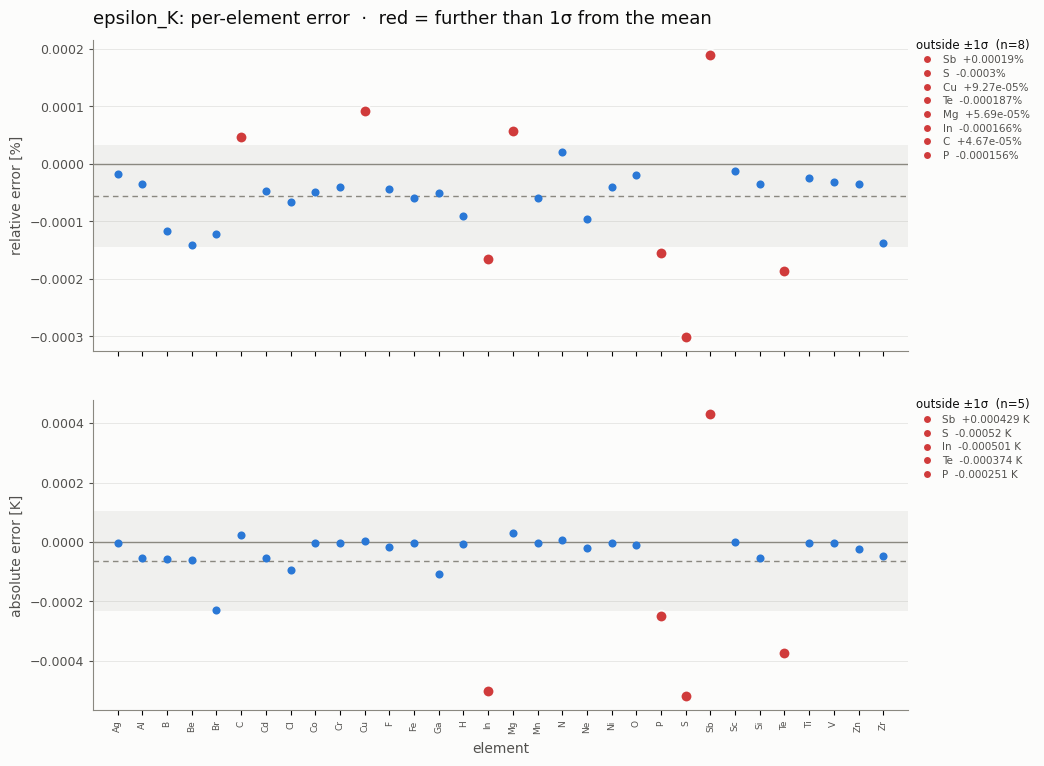

In [44]:
plot_error_profile(df_compare_both, "epsilon_K")

Bene comment (2026-08-17): 

looks good! max errors in the order of 0.0003%. 

### 3.2 Compare Vincents UFF parameters 

In [45]:
df_compare_both = get_error_force_field(uff_vincent)

given df has 103 parameter entries for 103 unique elements.
# uff parameters: 103, # dreiding parameters: 0
comparing entries to 103 UFF parameters:
___UFF___
Lw is called Lr (i.e. the same element) in provided ff. renaming Lr to Lw in provided ff.
103/103 elements provided (for this ff): {'Tm', 'P', 'Tc', 'Os', 'Na', 'Sc', 'Es', 'Xe', 'In', 'B', 'S', 'Se', 'As', 'C', 'Fr', 'Y', 'Hf', 'Ge', 'Cl', 'Ne', 'Bi', 'H', 'Np', 'Rh', 'Hg', 'No', 'He', 'Re', 'N', 'Md', 'Nb', 'U', 'Mn', 'Cf', 'Zn', 'At', 'Sm', 'Ti', 'Si', 'Co', 'Mo', 'Lu', 'Pa', 'Pu', 'Dy', 'Br', 'Eu', 'Sn', 'Fm', 'Pt', 'Al', 'Bk', 'Ni', 'Ru', 'Pb', 'Cr', 'Ta', 'Cu', 'Ir', 'Fe', 'Sr', 'Ga', 'Nd', 'Li', 'Th', 'Au', 'I', 'Tl', 'O', 'Cd', 'Mg', 'Yb', 'Rb', 'Pd', 'Ar', 'Be', 'Pm', 'Po', 'V', 'Sb', 'Cm', 'Ho', 'W', 'Am', 'K', 'Er', 'Pr', 'Zr', 'Ca', 'Tb', 'Ra', 'Ce', 'Kr', 'Gd', 'Ag', 'Lw', 'Te', 'F', 'Ac', 'La', 'Ba', 'Rn', 'Cs'}.
0/103 elements missing (for this ff): set().
of the 103 elements provided, the average absolute error in

(<Figure size 2163.5x820 with 2 Axes>,
    element           panel     value  deviation_std
 0       Zn  relative error  0.000019       2.064972
 1       Ir  relative error  0.000019       2.044197
 2       Mn  relative error  0.000019       2.013733
 3       Na  relative error  0.000018       2.008460
 4       Ag  relative error -0.000018       1.727731
 ..     ...             ...       ...            ...
 80      Lu  absolute error  0.000029       1.074431
 81       H  absolute error -0.000034       1.046826
 82      Sb  absolute error  0.000028       1.040413
 83      Ru  absolute error -0.000033       1.019660
 84      Rn  absolute error -0.000032       1.002317
 
 [85 rows x 4 columns])

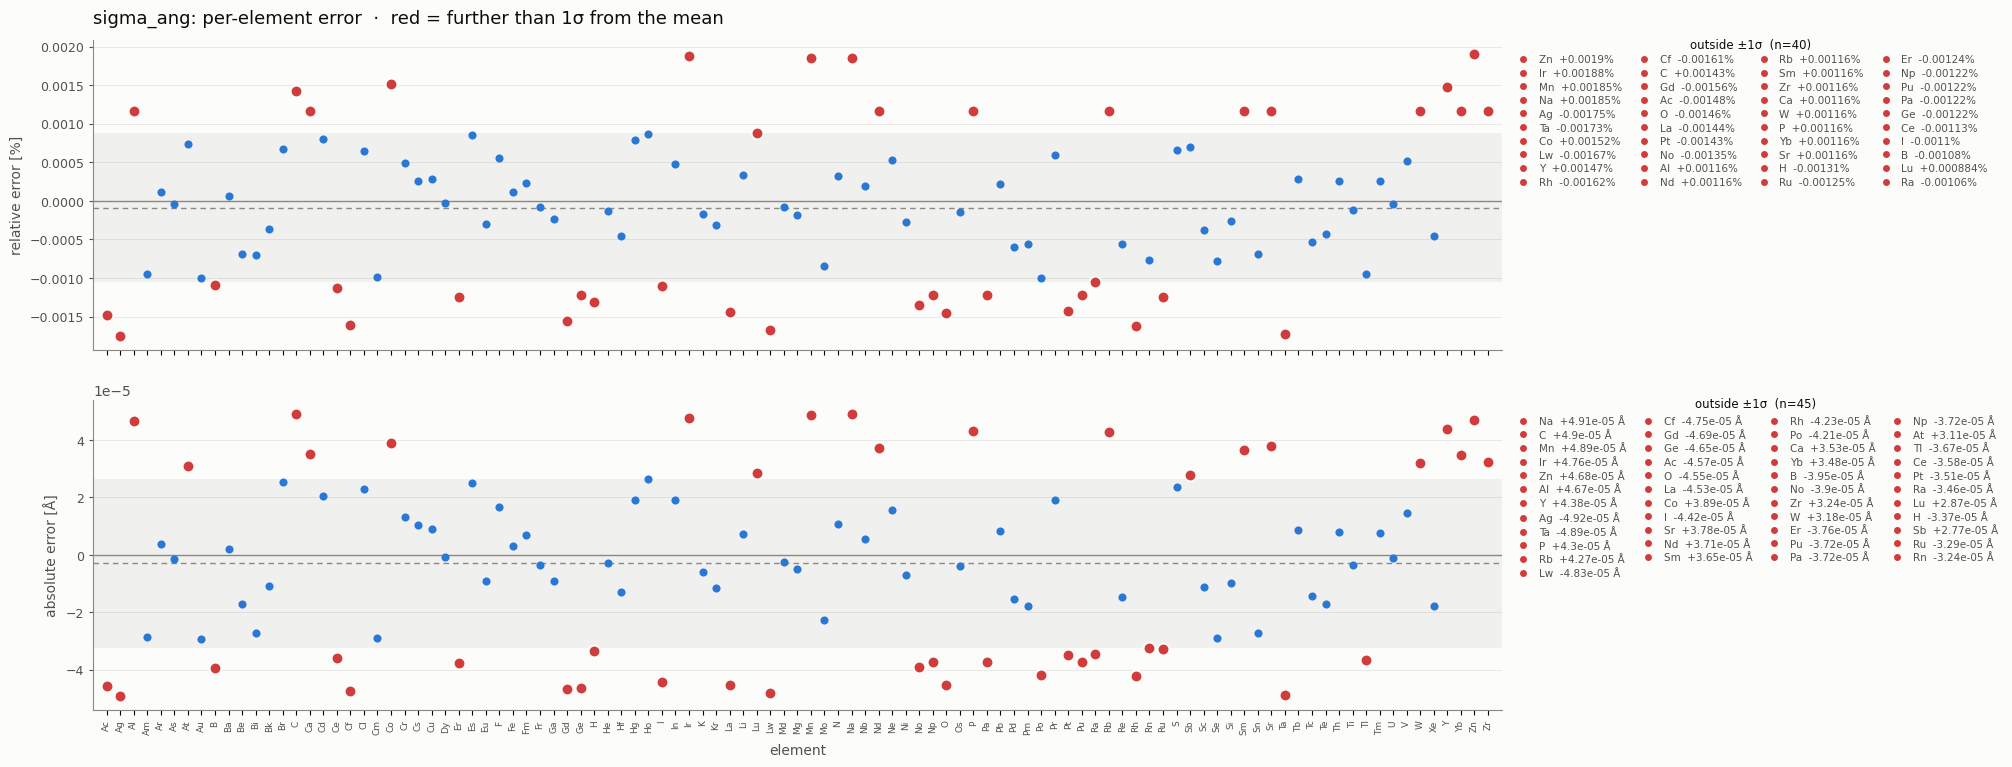

In [46]:
plot_error_profile(df_compare_both, "sigma_ang")

In [47]:
df_compare_both.keys()

Index(['element', 'sigma_ang_provided', 'epsilon_K_provided', 'mass_amu',
       'source', 'nonbond_distance_x1_ang', 'nonbond_energy_D1_kcal_mol',
       'sigma_ang_UFF', 'epsilon_K_UFF', 'sigma_ang_abs_error',
       'sigma_ang_rel_error', 'epsilon_K_abs_error', 'epsilon_K_rel_error',
       'R0_ang', 'D0_kcal_mol', 'sigma_ang_DREIDING', 'epsilon_K_DREIDING'],
      dtype='object')

(<Figure size 1843.5x820 with 2 Axes>,
    element           panel     value  deviation_std
 0       Cu  relative error  0.000120       5.185391
 1       Tm  relative error  0.000094       2.820081
 2       Gd  relative error  0.000094       2.820081
 3       Pm  relative error  0.000094       2.820081
 4       Sm  relative error  0.000110       2.183339
 5       Es  relative error  0.000110       2.183339
 6       Eu  relative error  0.000110       2.183339
 7       Fm  relative error  0.000110       2.183339
 8       Pu  relative error  0.000098       1.569226
 9        V  relative error  0.000098       1.569226
 10      Np  relative error  0.000108       1.393325
 11      Sc  relative error  0.000108       1.393325
 12      Mn  relative error  0.000099       1.280567
 13      Cm  relative error  0.000099       1.280567
 14      Cf  relative error  0.000099       1.280567
 15      Ce  relative error  0.000099       1.280567
 16      Fe  relative error  0.000099       1.280567
 17    

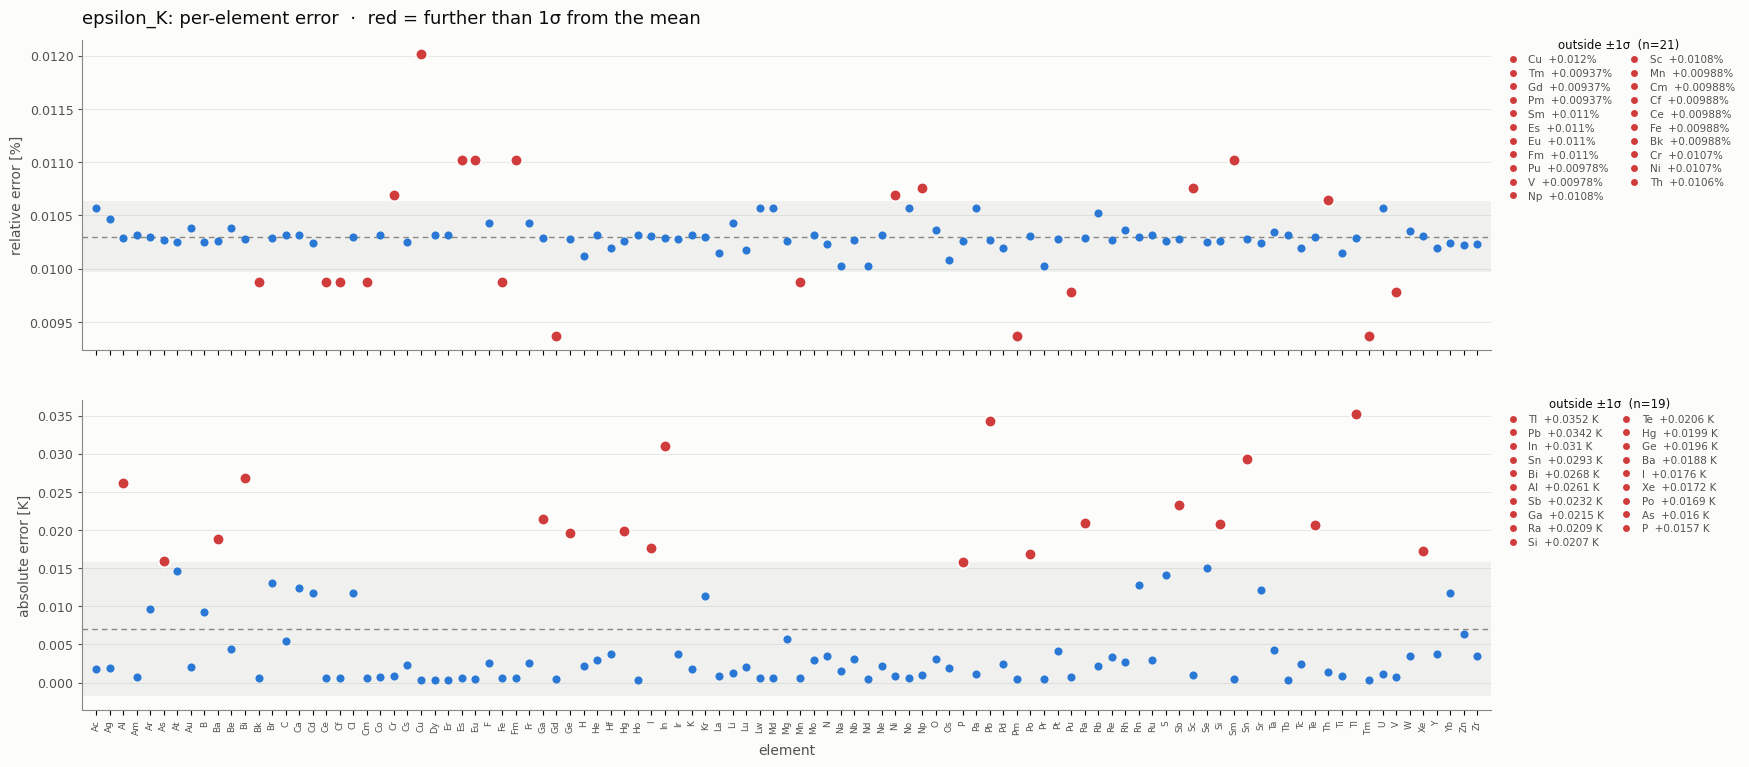

In [48]:
plot_error_profile(df_compare_both, "epsilon_K")

Bene comment (2026-08-17): 

max error in the order of 0.003%, a bit larger than for RASPA2, but still great. its a bit weird that the epsilon values are all slightly larger than the original data (difference over set is not centered around 0 but slightly positive...)

### 3.3 Compare Wei's UFF/DREIDING parameters

In [49]:
df_compare_both = get_error_force_field(ff_wei)

given df has 95 parameter entries for 95 unique elements.
# uff parameters: 74, # dreiding parameters: 21
comparing entries to 103 UFF parameters:
___UFF___
74/103 elements provided (for this ff): {'Ho', 'W', 'Bk', 'Am', 'K', 'Ni', 'Ru', 'Pr', 'Er', 'Np', 'Rh', 'Cr', 'Zr', 'Ca', 'Tb', 'Tm', 'Ce', 'Ta', 'Cu', 'Hg', 'Ir', 'Tc', 'Fe', 'Pb', 'Ra', 'Re', 'Os', 'No', 'Sr', 'Na', 'Sc', 'Nd', 'Nb', 'Gd', 'Es', 'U', 'Mn', 'Th', 'Cf', 'Ag', 'Md', 'Zn', 'Au', 'Sm', 'At', 'Ti', 'Tl', 'Cd', 'Co', 'Cs', 'Mg', 'Yb', 'Mo', 'Rb', 'Lu', 'Ac', 'Hf', 'Pa', 'Pu', 'Pd', 'Dy', 'Eu', 'Be', 'La', 'V', 'Ba', 'Pm', 'Bi', 'Po', 'Rn', 'Y', 'Fm', 'Cm', 'Pt'}.
29/103 elements missing (for this ff): {'H', 'P', 'Kr', 'He', 'Ga', 'N', 'Xe', 'Li', 'In', 'I', 'B', 'Lw', 'S', 'Si', 'O', 'Se', 'As', 'Te', 'C', 'Fr', 'F', 'Ge', 'Cl', 'Br', 'Ne', 'Sn', 'Ar', 'Sb', 'Al'}.
of the 74 elements provided, the average absolute error in sigma is 0.0032 angstroms, and the average relative error is 0.1198%.
min absolute error in sigma

(<Figure size 1567.5x820 with 2 Axes>,
   element           panel     value  deviation_std
 0      Cr  relative error  0.088625       9.644196
 1      Cr  absolute error  0.238683       9.644196)

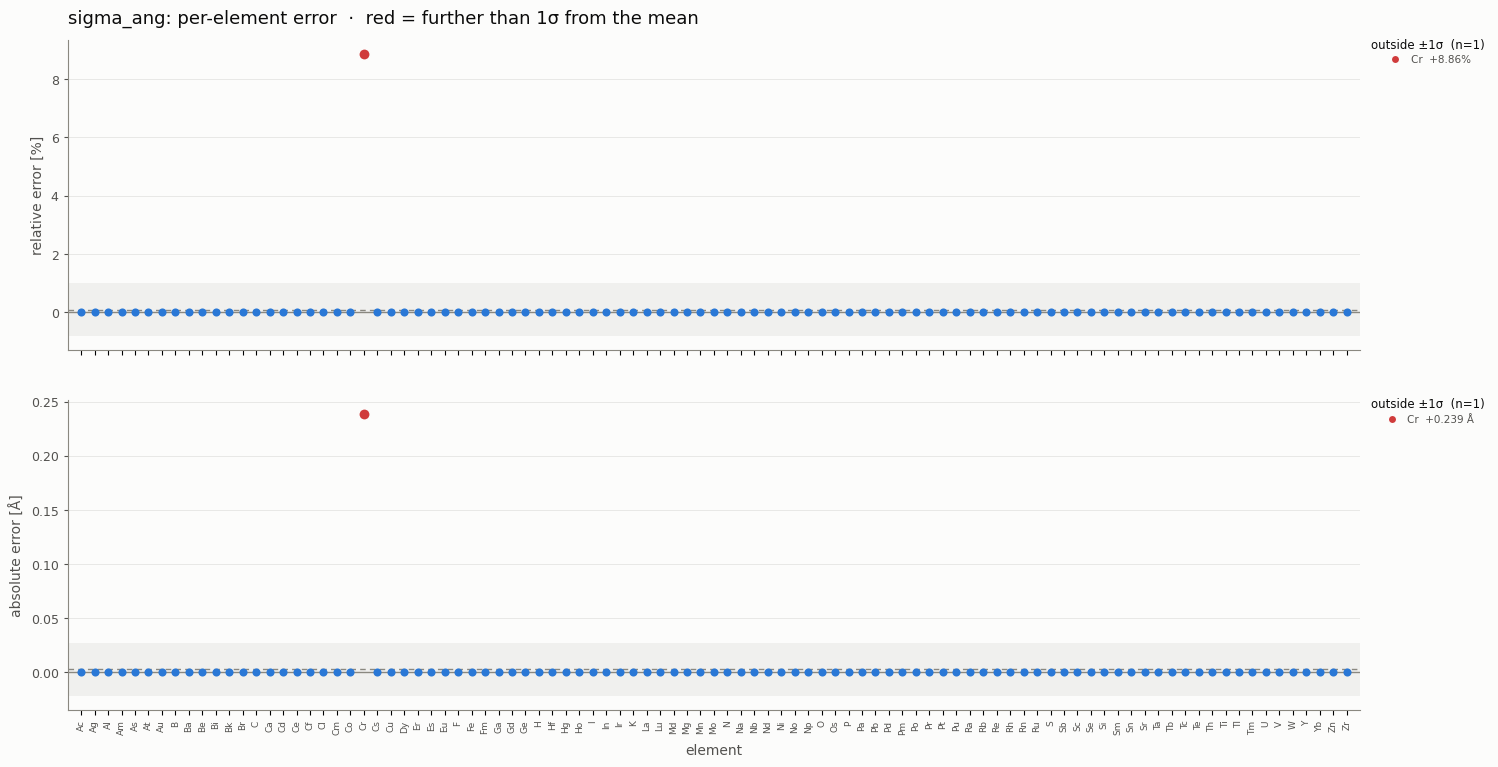

In [50]:
plot_error_profile(df_compare_both, "sigma_ang")

(<Figure size 1873x820 with 2 Axes>,
    element           panel     value  deviation_std
 0       Pt  relative error  0.000002       2.091269
 1       Re  relative error -0.000002       1.968173
 2       Mg  relative error  0.000002       1.920051
 3       Pd  relative error  0.000002       1.856345
 4       Es  relative error -0.000002       1.786672
 ..     ...             ...       ...            ...
 65      Hf  absolute error -0.000003       1.068859
 66       B  absolute error -0.000003       1.059419
 67      Gd  absolute error  0.000003       1.045116
 68      Ni  absolute error  0.000003       1.015295
 69      Be  absolute error  0.000003       1.010324
 
 [70 rows x 4 columns])

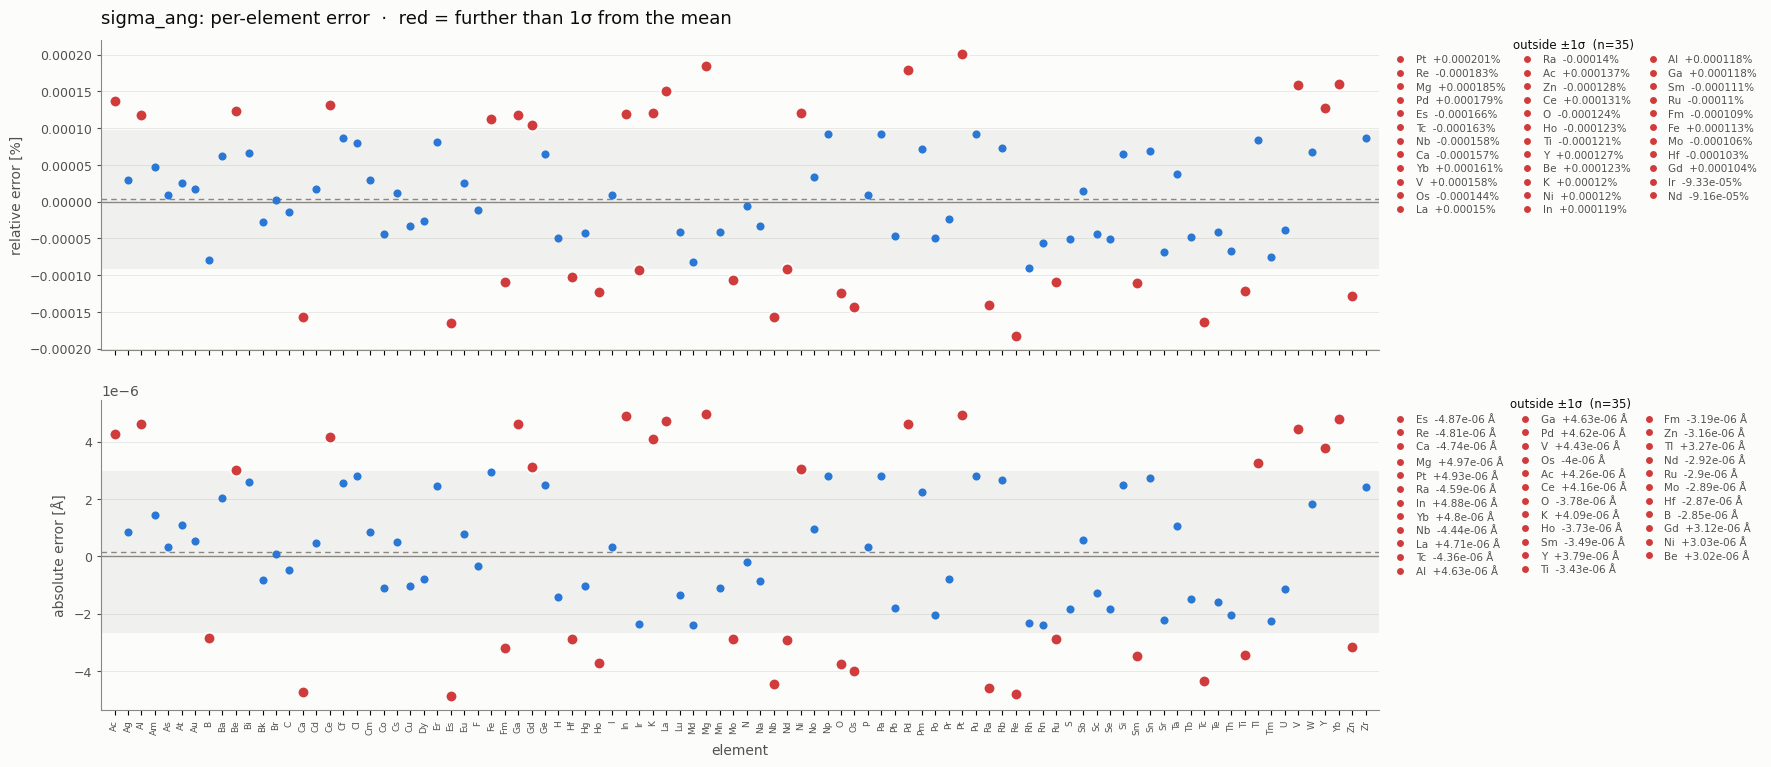

In [51]:
plot_error_profile(df_compare_both[~df_compare_both["element"].isin(["Cr"])], "sigma_ang")

(<Figure size 1567.5x820 with 2 Axes>,
   element           panel     value  deviation_std
 0      Mo  relative error  0.053571       9.644196
 1      Mo  absolute error  1.509656       9.644196)

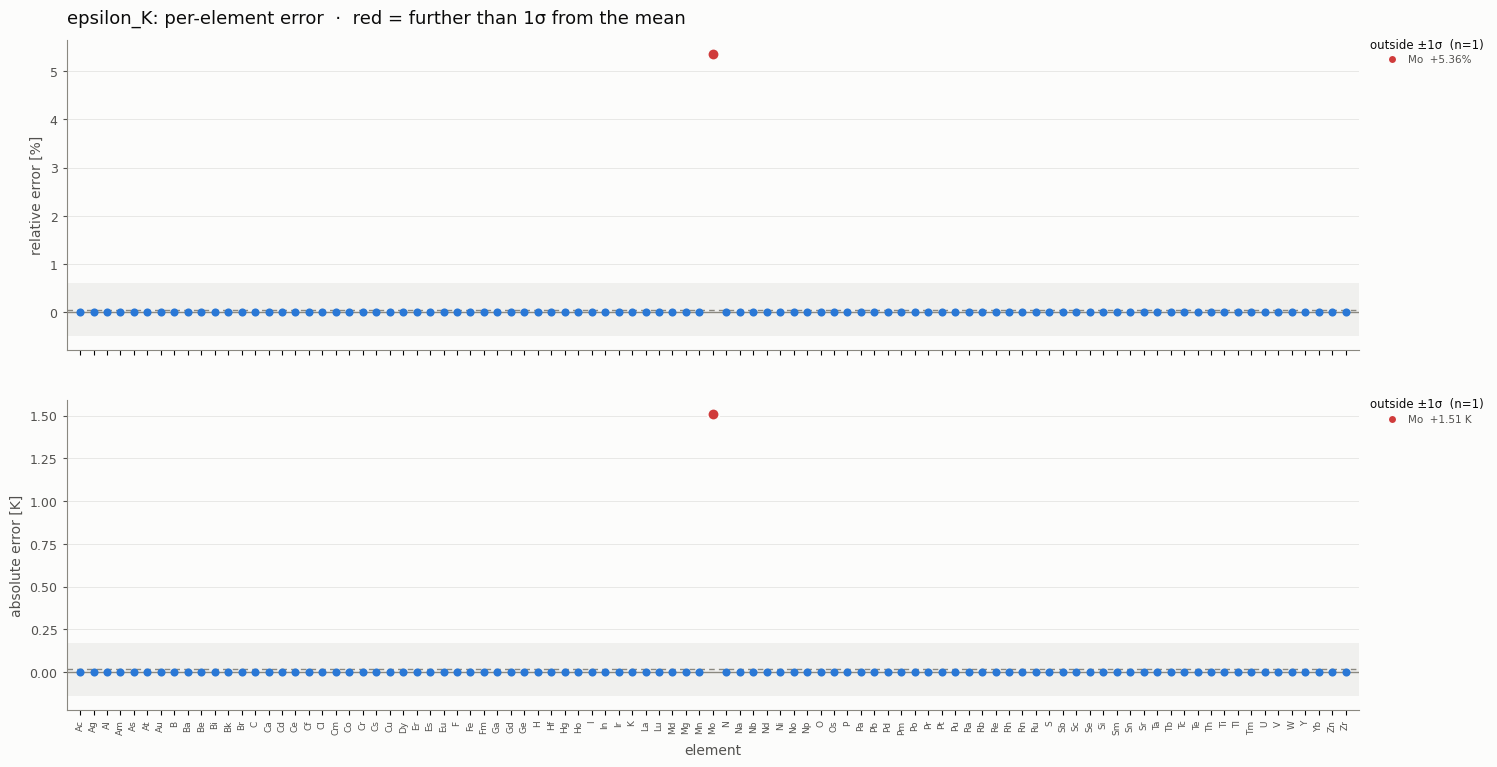

In [52]:
plot_error_profile(df_compare_both, "epsilon_K")

(<Figure size 1873x820 with 2 Axes>,
    element           panel         value  deviation_std
 0        B  relative error -1.164761e-06       2.782245
 1       Gd  relative error  9.270332e-07       1.858849
 2       Pm  relative error  9.270332e-07       1.858849
 3       No  relative error  9.270332e-07       1.858849
 4       Md  relative error  9.270332e-07       1.858849
 5       Tm  relative error  9.270332e-07       1.858849
 6       Dy  relative error  9.270332e-07       1.858849
 7       Er  relative error  9.270332e-07       1.858849
 8       Tb  relative error  9.270332e-07       1.858849
 9       Ho  relative error  9.270332e-07       1.858849
 10      Sm  relative error  9.270332e-07       1.858849
 11      Eu  relative error  9.270332e-07       1.858849
 12      Pr  relative error  9.270332e-07       1.858849
 13      Cu  relative error  9.270332e-07       1.858849
 14      Nd  relative error  9.270332e-07       1.858849
 15      Es  relative error -7.289703e-07       1.8

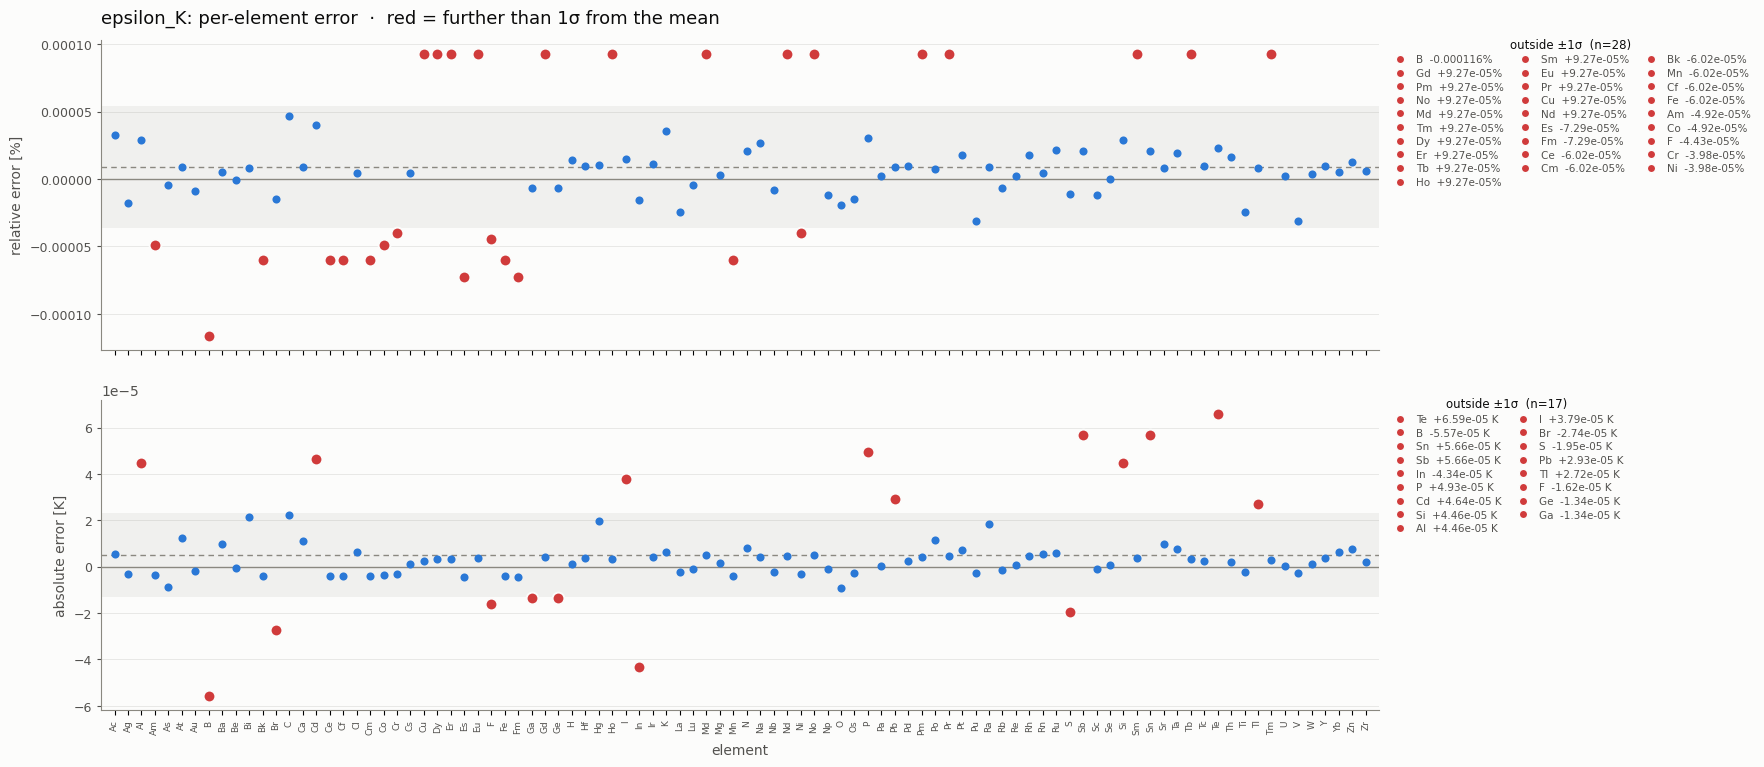

In [53]:
plot_error_profile(df_compare_both[~df_compare_both["element"].isin(["Mo"])], "epsilon_K")

In [54]:
df_compare_both[df_compare_both["element"].isin(["Cr", "Mo"])]

,element,sigma_ang_provided,epsilon_K_provided,mass_amu,source,nonbond_distance_x1_ang,nonbond_energy_D1_kcal_mol,sigma_ang_UFF,epsilon_K_UFF,sigma_ang_abs_error,sigma_ang_rel_error,epsilon_K_abs_error,epsilon_K_rel_error,R0_ang,D0_kcal_mol,sigma_ang_DREIDING,epsilon_K_DREIDING
7,Cr,2.93187,7.54829,51.9961,UFF,3.023,0.015,2.693187,7.548293,0.238683,0.088625,-0.000003,-3.977696e-07,NaN,NaN,NaN,NaN
15,Mo,2.71902,29.68995,95.9400,UFF,3.052,0.056,2.719023,28.180294,-0.000003,-0.000001,1.509656,5.357134e-02,NaN,NaN,NaN,NaN


In [55]:
# check outliers (manually selected)
df_compare_both[df_compare_both["element"].isin(["Cr", "Mo"])][["element", "sigma_ang_provided", "sigma_ang_UFF", "sigma_ang_abs_error", "sigma_ang_rel_error", "epsilon_K_provided", "epsilon_K_UFF", "epsilon_K_abs_error", "epsilon_K_rel_error"]]

,element,sigma_ang_provided,sigma_ang_UFF,sigma_ang_abs_error,sigma_ang_rel_error,epsilon_K_provided,epsilon_K_UFF,epsilon_K_abs_error,epsilon_K_rel_error
7,Cr,2.93187,2.693187,0.238683,0.088625,7.54829,7.548293,-0.000003,-3.977696e-07
15,Mo,2.71902,2.719023,-0.000003,-0.000001,29.68995,28.180294,1.509656,5.357134e-02


In [56]:
df_compare_both2 = get_error_force_field(ff_wei[~ff_wei["element"].isin(["Cr", "Mo"])])

given df has 93 parameter entries for 93 unique elements.
# uff parameters: 72, # dreiding parameters: 21
comparing entries to 103 UFF parameters:
___UFF___
72/103 elements provided (for this ff): {'Ho', 'W', 'Bk', 'Am', 'K', 'Ni', 'Ru', 'Pr', 'Er', 'Np', 'Rh', 'Zr', 'Tm', 'Ca', 'Tb', 'Ta', 'Ce', 'Hg', 'Cu', 'Pb', 'Ir', 'Tc', 'Fe', 'Ra', 'No', 'Re', 'Os', 'Sr', 'Na', 'Sc', 'Nd', 'Nb', 'Gd', 'Es', 'U', 'Mn', 'Th', 'Cf', 'Ag', 'Md', 'Zn', 'Au', 'Sm', 'At', 'Ti', 'Tl', 'Cd', 'Co', 'Cs', 'Mg', 'Yb', 'Rb', 'Lu', 'Ac', 'Hf', 'Pa', 'Pu', 'Pd', 'Dy', 'Eu', 'Be', 'La', 'V', 'Ba', 'Pm', 'Bi', 'Po', 'Rn', 'Y', 'Fm', 'Cm', 'Pt'}.
31/103 elements missing (for this ff): {'H', 'Cr', 'P', 'Kr', 'He', 'Ga', 'N', 'Xe', 'Li', 'In', 'I', 'B', 'Lw', 'S', 'Si', 'O', 'Se', 'Mo', 'As', 'Te', 'C', 'Fr', 'F', 'Ge', 'Cl', 'Br', 'Ne', 'Sn', 'Ar', 'Sb', 'Al'}.
of the 72 elements provided, the average absolute error in sigma is 0.0000 angstroms, and the average relative error is 0.0000%.
min absolute error in sigma

Bene comment (2026-08-17): 

Set has 2 clear outliers: Cr (sigma is 0.2387 angstroms or 8.8625% above UFF) and Mo (epsilon is 1.5097 K or 5.3571% above UFF). The rest looks great (order of difference similar to RASPA2 parameters: 0.0002% and centered around 0).

### 3.4 test ff

In [57]:
df_compare_both = get_error_force_field(test_ff)

given df has 2 parameter entries for 2 unique elements.
# uff parameters: 2, # dreiding parameters: 0
comparing entries to 103 UFF parameters:
___UFF___
2/103 elements provided (for this ff): {'Ag', 'Ac'}.
101/103 elements missing (for this ff): {'Bk', 'Ni', 'Ru', 'Pb', 'Cr', 'Tm', 'Ta', 'Cu', 'P', 'Tc', 'Ir', 'Fe', 'Os', 'Pt', 'Sr', 'Ga', 'Na', 'Sc', 'Es', 'Nd', 'Xe', 'Li', 'Th', 'In', 'Au', 'I', 'B', 'Tl', 'S', 'O', 'Cd', 'Mg', 'Se', 'Yb', 'As', 'C', 'Fr', 'Rb', 'Hf', 'Pd', 'Ge', 'Cl', 'Ne', 'Be', 'Ar', 'V', 'Bi', 'Pm', 'Po', 'Sb', 'Cm', 'H', 'Ho', 'W', 'Am', 'K', 'Np', 'Pr', 'Er', 'Rh', 'Zr', 'Hg', 'Ca', 'Tb', 'Ra', 'Ce', 'No', 'Kr', 'He', 'Re', 'N', 'Nb', 'Md', 'U', 'Mn', 'Cf', 'Gd', 'Zn', 'Sm', 'At', 'Ti', 'Lw', 'Si', 'Co', 'Cs', 'Mo', 'Te', 'F', 'Lu', 'Pa', 'Pu', 'Dy', 'Eu', 'Br', 'Sn', 'La', 'Ba', 'Rn', 'Fm', 'Y', 'Al'}.
of the 2 elements provided, the average absolute error in sigma is -0.5000 angstroms, and the average relative error is -17.8298%.
min absolute error in sigma i

In [60]:
df_compare_both["sigma_ang_rel_error"].min()

np.float64(-0.356581078089497)